# Heart Disease Prediction

**Goal:** predict the presence of heart disease (`target`: 1 = disease, 0 = healthy)
from clinical measurements.



1. Loading and data-quality checks (including a large duplicate block)
2. Exploratory data analysis (EDA)
3. Preprocessing pipeline (scale numerics, one-hot encode clinical categoricals)
4. Cross-validated model comparison
5. Hyperparameter tuning and final evaluation
6. Feature importance and summary

**Dataset:** the UCI/Kaggle heart dataset (1,025 rows, 13 features). Note: 723 of
those rows are exact duplicates, leaving 302 unique patients.

## 1. Setup and data loading

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
)

RANDOM_STATE = 2026
sns.set_theme(style="whitegrid")

In [6]:
df = pd.read_csv("heart.csv")
print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 2. Data-quality checks

This dataset is famous for containing many duplicated rows. Leaving them in leaks
identical patients across the train/test split and inflates the score, so we drop
them before doing anything else.

In [7]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
print("Unique patients:", len(df))
df["target"].value_counts()

Missing values: 0
Duplicate rows: 1
Unique patients: 302


target
1    164
0    138
Name: count, dtype: int64

## 3. Exploratory data analysis

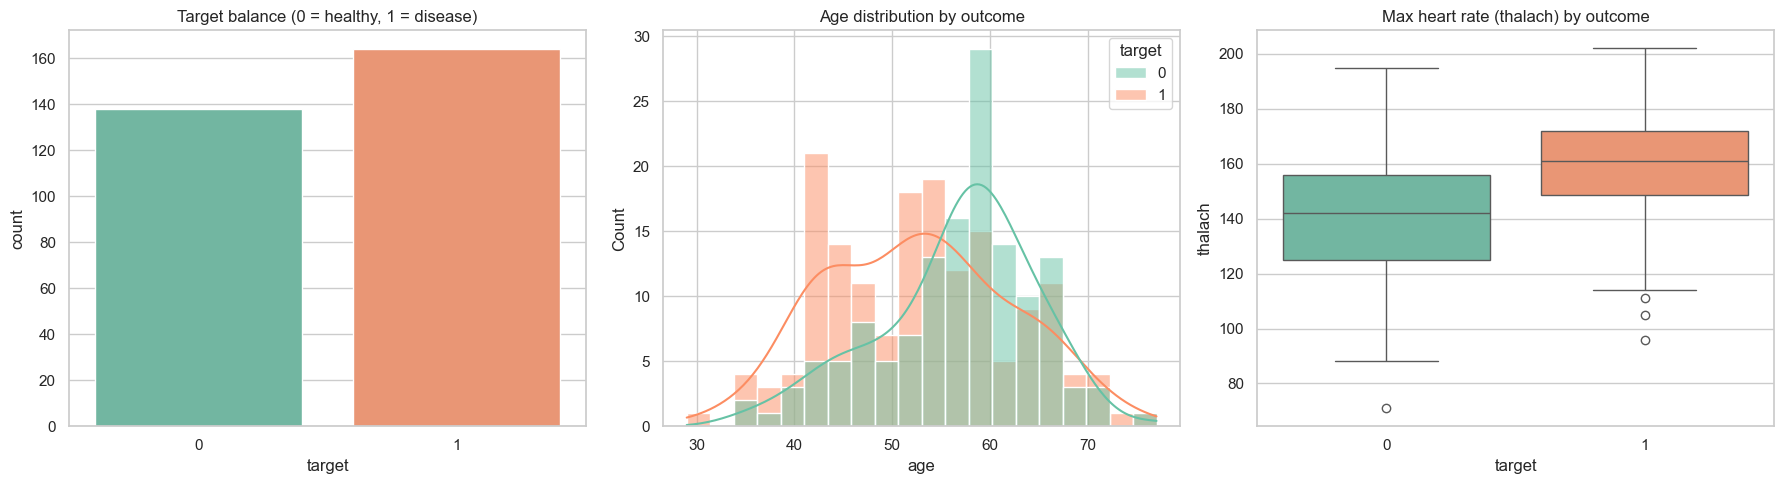

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="target", ax=axes[0], palette="Set2", hue="target", legend=False)
axes[0].set_title("Target balance (0 = healthy, 1 = disease)")

sns.histplot(data=df, x="age", hue="target", bins=20, kde=True, ax=axes[1], palette="Set2")
axes[1].set_title("Age distribution by outcome")

sns.boxplot(data=df, x="target", y="thalach", ax=axes[2], palette="Set2", hue="target", legend=False)
axes[2].set_title("Max heart rate (thalach) by outcome")
plt.tight_layout()
plt.show()

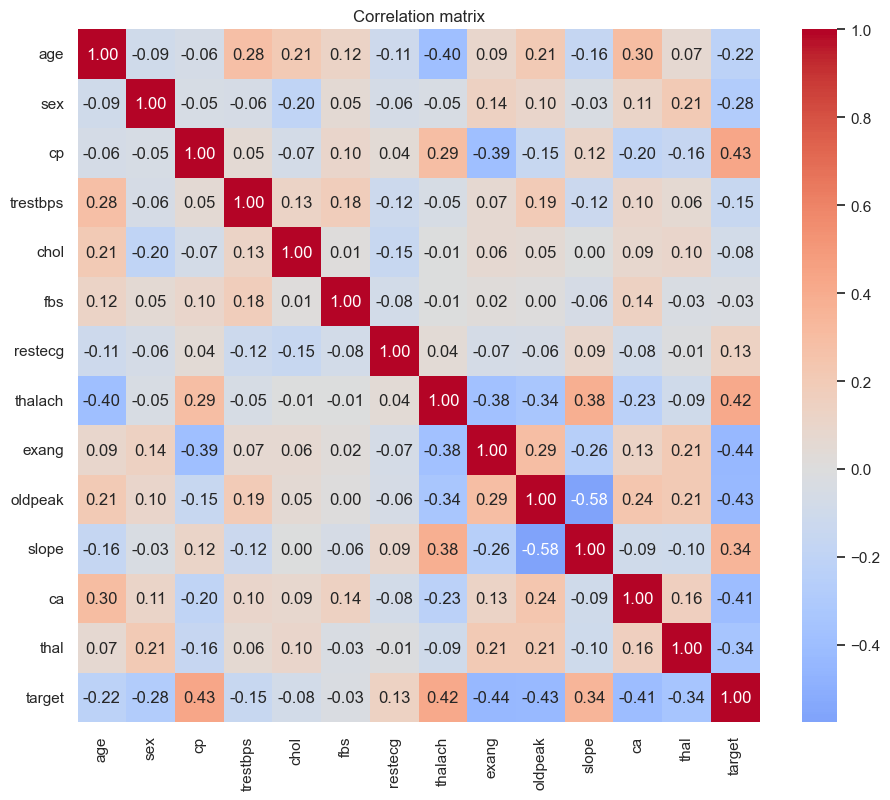

exang      -0.435601
oldpeak    -0.429146
ca         -0.408992
thal       -0.343101
sex        -0.283609
age        -0.221476
trestbps   -0.146269
chol       -0.081437
fbs        -0.026826
restecg     0.134874
slope       0.343940
thalach     0.419955
cp          0.432080
Name: target, dtype: float64

In [9]:
plt.figure(figsize=(11, 9))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

df.corr()["target"].drop("target").sort_values()

## 4. Preprocessing pipeline

Although every column is numeric, several are really **categorical codes**
(chest-pain type, resting ECG, slope, number of vessels, thalassemia). We one-hot
encode those and standardize the truly continuous measurements, all inside a
`Pipeline` so transforms are fit on the training fold only.

In [10]:
categorical_features = ["cp", "restecg", "slope", "ca", "thal", "sex", "fbs", "exang"]
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

X = df.drop(columns="target")
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (226, 13) | Test: (76, 13)


## 5. Model comparison (5-fold cross-validation)

In [11]:
candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
}

rows = []
for name, est in candidates.items():
    pipe = Pipeline([("prep", preprocessor), ("model", est)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="roc_auc", n_jobs=-1)
    rows.append({"model": name, "cv_roc_auc": scores.mean(), "cv_std": scores.std()})
    print(f"{name:<22} ROC AUC {scores.mean():.4f} +/- {scores.std():.4f}")

cv_results = pd.DataFrame(rows).sort_values("cv_roc_auc", ascending=False).reset_index(drop=True)
cv_results

Logistic Regression    ROC AUC 0.9155 +/- 0.0112
KNN                    ROC AUC 0.8912 +/- 0.0126
SVM                    ROC AUC 0.9068 +/- 0.0086
Random Forest          ROC AUC 0.9092 +/- 0.0121
AdaBoost               ROC AUC 0.8940 +/- 0.0239


,model,cv_roc_auc,cv_std
0,Logistic Regression,0.915521,0.011177
1,Random Forest,0.909190,0.012114
2,SVM,0.906756,0.008606
3,AdaBoost,0.894006,0.023896
4,KNN,0.891163,0.012623


## 6. Hyperparameter tuning (Random Forest)

In [12]:
rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])
param_dist = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}
search = RandomizedSearchCV(rf_pipe, param_dist, n_iter=20, cv=5,
                            scoring="roc_auc", random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
search.fit(X_train, y_train)
print("Best CV ROC AUC:", round(search.best_score_, 4))
for k, v in search.best_params_.items():
    print(f"  {k} = {v}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV ROC AUC: 0.9191
  model__n_estimators = 200
  model__min_samples_leaf = 2
  model__max_features = log2
  model__max_depth = 5


## 7. Final evaluation

Note the correct argument order: `accuracy_score(y_true, y_pred)`. (The original
notebook reversed these in places, which silently swaps the class labels in the
classification report.)

In [13]:
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Test accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Test ROC AUC  :", round(roc_auc_score(y_test, y_proba), 4))
print()
print(classification_report(y_test, y_pred, target_names=["Healthy", "Disease"]))

Test accuracy : 0.8026
Test ROC AUC  : 0.901

              precision    recall  f1-score   support

     Healthy       0.86      0.69      0.76        35
     Disease       0.77      0.90      0.83        41

    accuracy                           0.80        76
   macro avg       0.81      0.79      0.80        76
weighted avg       0.81      0.80      0.80        76



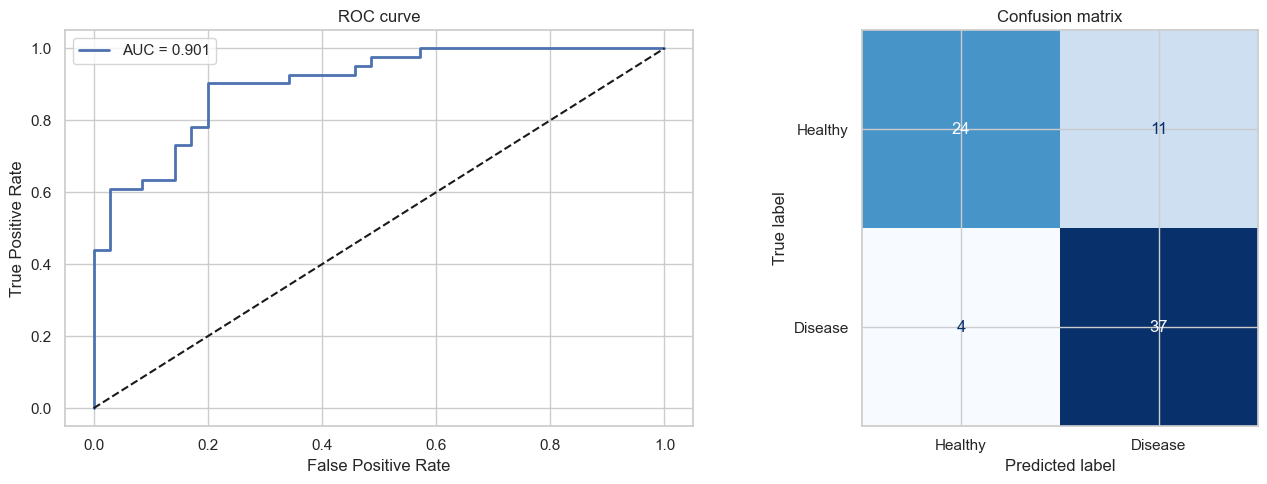

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve"); axes[0].legend()

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Healthy", "Disease"]).plot(cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion matrix")
plt.tight_layout(); plt.show()

## 8. Feature importance

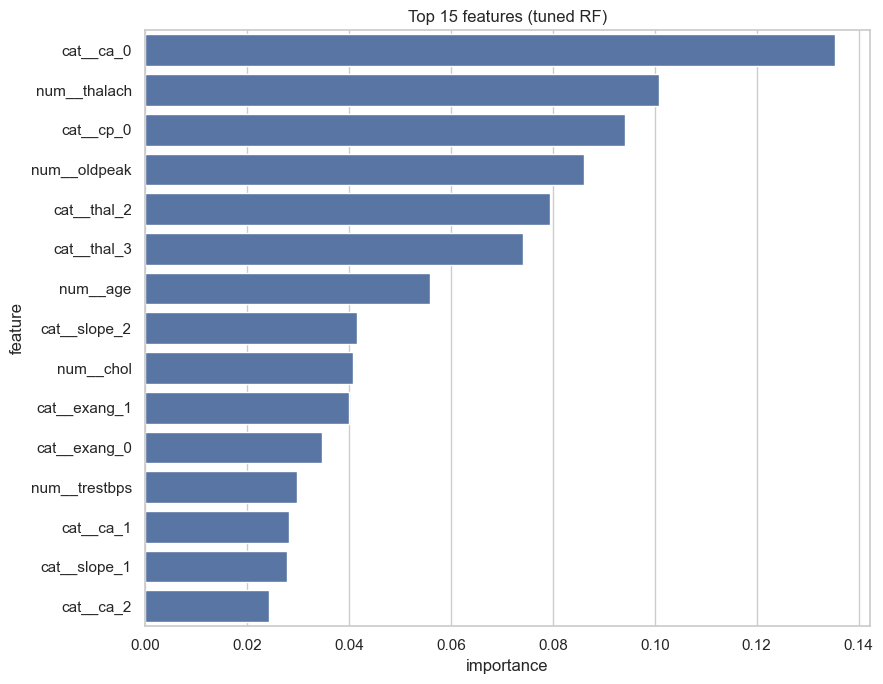

,feature,importance
0,cat__ca_0,0.135439
1,num__thalach,0.100791
2,cat__cp_0,0.094139
3,num__oldpeak,0.086087
4,cat__thal_2,0.079504
5,cat__thal_3,0.074052
6,num__age,0.055880
7,cat__slope_2,0.041516
8,num__chol,0.040727
9,cat__exang_1,0.040068


In [15]:
feature_names = best_model.named_steps["prep"].get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_
importance_df = (pd.DataFrame({"feature": feature_names, "importance": importances})
                 .sort_values("importance", ascending=False).reset_index(drop=True))
plt.figure(figsize=(9, 7))
sns.barplot(data=importance_df.head(15), x="importance", y="feature", color="#4c72b0")
plt.title("Top 15 features (tuned RF)")
plt.tight_layout(); plt.show()
importance_df.head(15)

## 9. Summary

- Dropped 723 duplicate rows up front — the single most important fix, since
  duplicates leak identical patients across the split.
- Treated clinical codes as categorical (one-hot) rather than as numbers, inside a
  leakage-free pipeline.
- Compared five model families with cross-validated ROC AUC, then tuned the best.
- Reported metrics with the correct `(y_true, y_pred)` argument order.

Chest-pain type, number of major vessels (`ca`), and max heart rate are the
strongest predictors. **Possible extensions:** probability calibration and SHAP
explanations for individual patients.